# fashion_minst分类实战

In [1]:
import torch
from torchvision import datasets, transforms

# 定义数据预处理
transform = transforms.Compose([
    transforms.ToTensor(),#将PIL.Image变换成torch.Tensor，并且将像素值归一化到[0,1]
    transforms.Normalize((0.285,), (0.352,)),  # 标准化：均值0.5，标准差0.5，将像素分布到[-1,1]
])

# 下载并加载训练数据集
full_train_dataset = datasets.FashionMNIST(root='./data', train=True, download=False, transform=transform)

# 从训练集中分出5000样本作为验证集
train_size = len(full_train_dataset) - 5000
val_size = 5000

#random_split打乱样本
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size],generator=generator)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)  # batch_size是一个批次样本的数量
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

# 下载并加载测试数据集
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=False, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [2]:
# 计算train_dataset的所有图像的均值和标准差
import numpy as np

# 将train_dataset的所有图片展开并拼接，获得像素值
all_imgs = []
for i in range(len(train_dataset)):
    img = train_dataset[i][0].numpy()  # (1,28,28)
    all_imgs.append(img)
all_imgs = np.concatenate(all_imgs, axis=0)  # (N,28,28) 拼成 (N,28,28)（或更精确地是(55000,1,28,28)拼成(55000,28,28)）

# 因为ToTensor后是float,且train_dataset来自random_split（依然只有一通道），可直接求整体均值
mean = all_imgs.mean()
std = all_imgs.std()
print("Train mean:", mean)
print("Train std:", std)

Train mean: 0.0016071055
Train std: 1.0020698


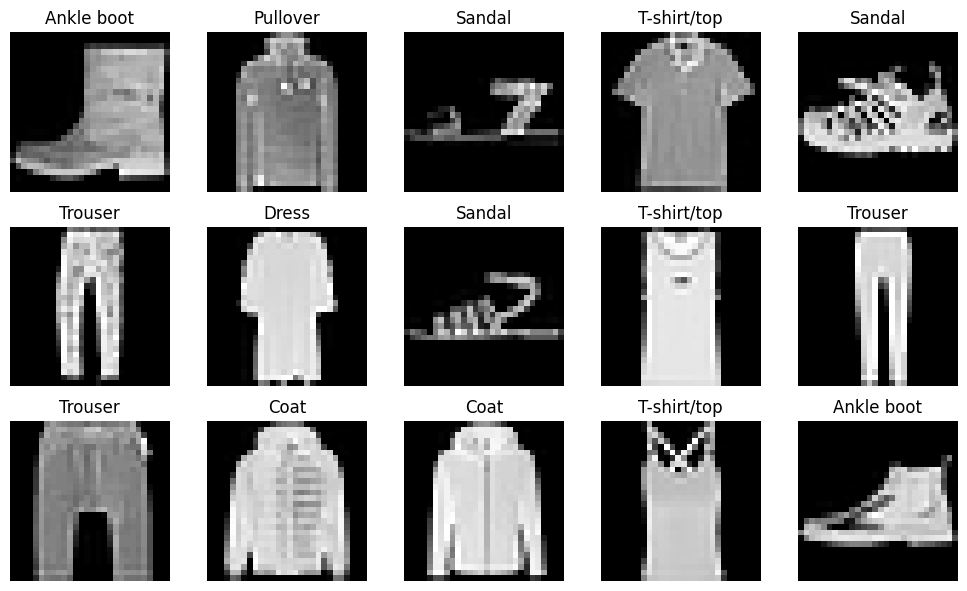

In [3]:
import matplotlib.pyplot as plt

# FashionMNIST类别名称
class_names = full_train_dataset.classes

# 可视化train_dataset前15个样本，并显示类别名称
fig, axs = plt.subplots(3, 5, figsize=(10, 6))
axs = axs.flatten()

for i in range(15):
    # 这里train_dataset[i]会返回(img, label)两个值，
    # img是第i个样本的图像（已做Tensor变换），label是对应的类别标签。
    # 因为train_dataset由torch.utils.data.random_split分割自原始的Dataset，继承了其__getitem__方法，原始FashionMNIST的__getitem__返回图像和标签两个值。
    img, label = train_dataset[i]
    img = img.squeeze().numpy()  # 变成2D numpy数组  将(1,28,28)压缩成(28,28)
    axs[i].imshow(img, cmap='gray')
    axs[i].set_title(class_names[label])
    axs[i].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import torch.nn as nn

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 300)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(100, 10)
        
    def forward(self, x):
        print("Before view:", x.shape)
        x = x.view(x.size(0), -1)  # 展平成(batch_size, 784)
        print("After view:", x.shape)
        x = self.fc1(x)
        print("After fc1:", x.shape)
        x = self.relu1(x)
        print("After relu1:", x.shape)
        x = self.fc2(x)
        print("After fc2:", x.shape)
        x = self.relu2(x)
        print("After relu2:", x.shape)
        x = self.fc3(x)
        print("After fc3:", x.shape)
        return x
   

In [5]:
import torch

img, label = train_dataset[0]
img = img.unsqueeze(0)  # 增加batch维度，形状变为(1, 1, 28, 28) 或 (1, 28, 28)
model = NeuralNetwork()
output = model(img)
print("Logits:", output)
print("Predicted class:", torch.argmax(output, dim=1).item(), "True class:", label)

Before view: torch.Size([1, 1, 28, 28])
After view: torch.Size([1, 784])
After fc1: torch.Size([1, 300])
After relu1: torch.Size([1, 300])
After fc2: torch.Size([1, 100])
After relu2: torch.Size([1, 100])
After fc3: torch.Size([1, 10])
Logits: tensor([[ 1.1667e-01, -7.1864e-02,  2.1513e-01, -2.4648e-01,  1.6606e-04,
         -1.3251e-01, -1.1251e-01,  2.1074e-01,  1.5577e-02,  1.8622e-02]],
       grad_fn=<AddmmBackward0>)
Predicted class: 2 True class: 9


In [6]:
for images, labels in train_loader:
    print("images shape:", images.shape) #(bs,ch,h,w)
    print("labels shape:", labels.shape) #(bs)
    break  # 只输出第一个batch

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])


In [7]:
output = model(images)
print("Logits:", output.shape)

Before view: torch.Size([64, 1, 28, 28])
After view: torch.Size([64, 784])
After fc1: torch.Size([64, 300])
After relu1: torch.Size([64, 300])
After fc2: torch.Size([64, 100])
After relu2: torch.Size([64, 100])
After fc3: torch.Size([64, 10])
Logits: torch.Size([64, 10])


In [8]:
#输出模型的参数，及总参数量
for name, param in model.named_parameters():
    print(f"Name: {name}, Shape: {param.shape}, Number of params: {param.numel()}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Name: fc1.weight, Shape: torch.Size([300, 784]), Number of params: 235200
Name: fc1.bias, Shape: torch.Size([300]), Number of params: 300
Name: fc2.weight, Shape: torch.Size([100, 300]), Number of params: 30000
Name: fc2.bias, Shape: torch.Size([100]), Number of params: 100
Name: fc3.weight, Shape: torch.Size([10, 100]), Number of params: 1000
Name: fc3.bias, Shape: torch.Size([10]), Number of params: 10
Total number of parameters: 266610


In [17]:
import torch.nn as nn
import torch.nn.init as init

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        layers = []
        input_dim = 28 * 28
        # 第一层
        linear = nn.Linear(input_dim, 100)
        init.xavier_uniform_(linear.weight)
        if linear.bias is not None:
            nn.init.zeros_(linear.bias)
        layers.append(linear)
        layers.append(nn.ReLU())
        # 19 hidden layers of (100, 100)
        for _ in range(18):
            linear = nn.Linear(100, 100)
            init.xavier_uniform_(linear.weight)
            if linear.bias is not None:
                nn.init.zeros_(linear.bias)
            layers.append(linear)
            layers.append(nn.ReLU())
        self.hidden = nn.Sequential(*layers)
        self.output = nn.Linear(100, 10)
        init.xavier_uniform_(self.output.weight)
        if self.output.bias is not None:
            nn.init.zeros_(self.output.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # 展平成(batch_size, 784)
        x = self.hidden(x)
        x = self.output(x)
        return x

In [18]:
model = NeuralNetwork()

In [19]:
import torch
import torch.optim as optim

# 判断设备：如果有GPU则用GPU，否则用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3. 设置交叉熵损失函数和SGD优化器
criterion = nn.CrossEntropyLoss()  # 默认求的是样本的平均损失
optimizer = optim.SGD(model.parameters(), lr=0.01)
   

Epoch [1/30], Step [100/860], Loss: 2.2661
Epoch [1/30], Step [200/860], Loss: 1.5656
Epoch [1/30], Step [300/860], Loss: 1.0849
Epoch [1/30], Step [400/860], Loss: 0.8835
Epoch [1/30], Step [500/860], Loss: 0.7877
Epoch [1/30], Step [600/860], Loss: 0.9402
Epoch [1/30], Step [700/860], Loss: 0.6349
Epoch [1/30], Step [800/860], Loss: 0.4869
Epoch [1/30], Train Loss: 1.1147, Train Acc: 78.27%, Val Loss: 0.6374, Val Acc: 77.30%
Epoch [2/30], Step [100/860], Loss: 0.4634
Epoch [2/30], Step [200/860], Loss: 0.7240
Epoch [2/30], Step [300/860], Loss: 0.7789
Epoch [2/30], Step [400/860], Loss: 0.5377
Epoch [2/30], Step [500/860], Loss: 0.3622
Epoch [2/30], Step [600/860], Loss: 0.4070
Epoch [2/30], Step [700/860], Loss: 0.4687
Epoch [2/30], Step [800/860], Loss: 0.4011
Epoch [2/30], Train Loss: 0.5289, Train Acc: 84.36%, Val Loss: 0.5060, Val Acc: 82.70%
Epoch [3/30], Step [100/860], Loss: 0.3999
Epoch [3/30], Step [200/860], Loss: 0.4979
Epoch [3/30], Step [300/860], Loss: 0.7297
Epoch [3/

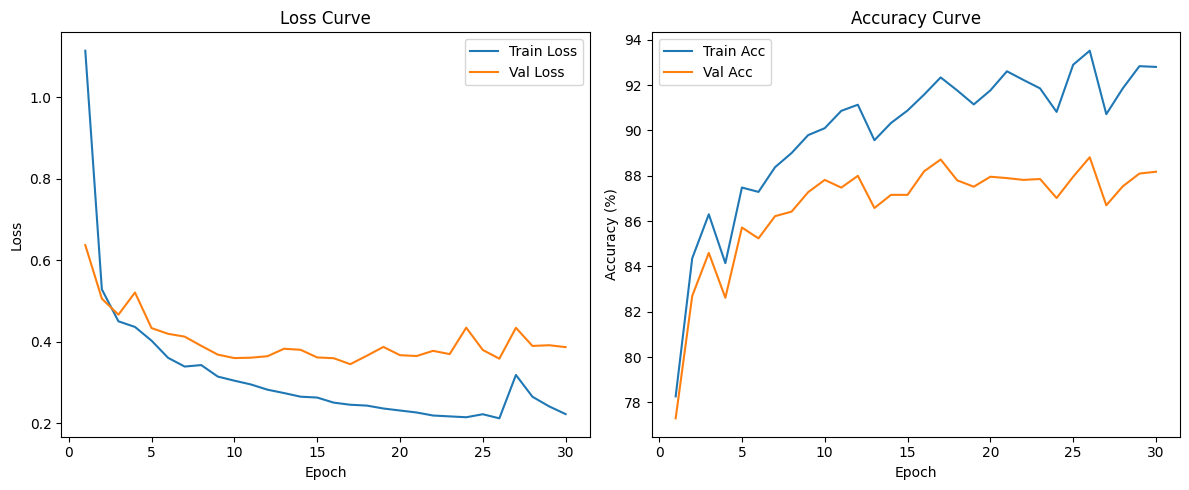

In [20]:
from model_train import Trainer
from importlib import reload
import model_train
reload(model_train)
from model_train import Trainer


# 将模型移至设备
model.to(device)

# 初始化Trainer，开启早停，并使用val_acc作为指标
trainer = Trainer(
    model, 
    train_loader, 
    val_loader, 
    lr=0.01, 
    momentum=0.9, 
    device=device, 
    early_stop=False,           # 启用早停
    early_stop_mode='val_acc', # 使用验证集准确率作为早停指标
    patience=5                 # 可自行调整容忍度
)
trainer.train(epochs=30)

# 画出损失与准确率曲线
trainer.plot_metrics()


Test Accuracy: 88.82%, Test Loss: 0.3280


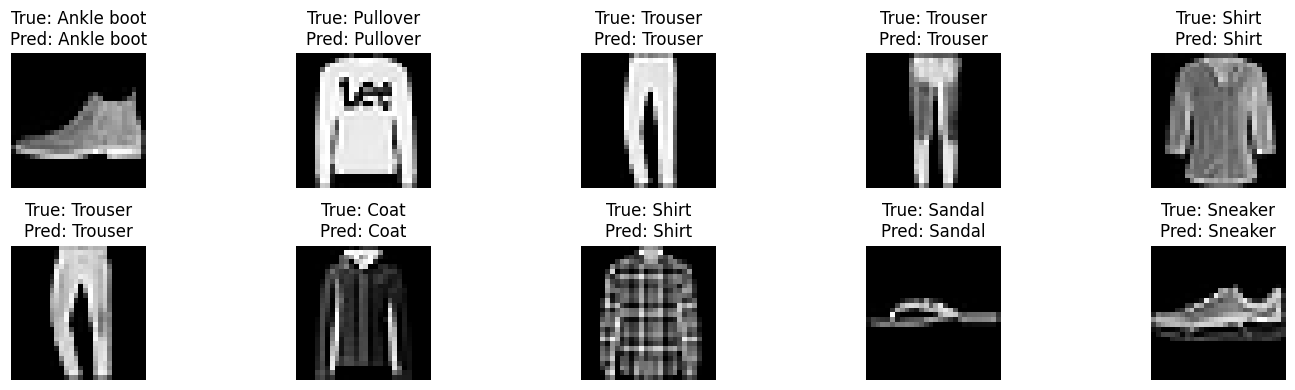

In [ ]:
# 在测试集上进行评估并画图

# 计算测试集上的准确率和损失
test_acc, test_loss = trainer.evaluating(test_loader)
print(f"Test Accuracy: {test_acc:.2f}%, Test Loss: {test_loss:.4f}")

# 可视化测试集上的预测结果
import matplotlib.pyplot as plt
import numpy as np

# 获取一组样本数据
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# 模型预测
model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# 随机选取前10个样本进行可视化
fig = plt.figure(figsize=(15,4))
class_names = test_loader.dataset.classes if hasattr(test_loader.dataset, "classes") else [str(i) for i in range(10)]
for idx in range(10):
    ax = fig.add_subplot(2,5,idx+1)
    img = images[idx].cpu().numpy()
    # 若为灰度图，需要去掉channel维度
    if img.shape[0] == 1:
        img_show = img[0]
        plt.imshow(img_show, cmap="gray")
    else:
        img_show = np.transpose(img, (1,2,0))
        plt.imshow(img_show)
    ax.set_title(f"True: {class_names[labels[idx].item()]}\nPred: {class_names[predicted[idx].item()]}")
    plt.axis("off")
plt.tight_layout()
plt.show()